# 01 Model Optimization

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- **Save** a trained Keras model and **load** it back — the foundation of every deployment
- Know what **quantization** and **pruning** are for (this notebook explains the ideas; notebooks `04`, `05`, and `07` apply them hands-on)
- See why we optimize (smaller/faster model) instead of deploying only the full-precision model

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 08 "Deployment & Monitoring" — a model that leaves the notebook has to be saved first; that is where this starts.

**Used later in:** Course 11 (AIAT 125) — Unit 1, lesson 04 "Preparing a Model for Deployment: The Full Save/Load/Predict Cycle".

---

## 🌍 Real life

**📌 Real case — 240 MB down to 6.9 MB, with no loss of accuracy.** Han, Mao and Dally's **Deep Compression** (ICLR 2016 — reference 1 below) combined pruning, trained quantization and Huffman coding and reported reducing storage "by 35× to 49× without affecting their accuracy": **AlexNet from 240 MB to 6.9 MB** and **VGG-16 from 552 MB to 11.3 MB**. Those are the numbers that turned "put the model on the phone" from impossible into routine, and every technique in the rest of this unit — pruning (`04`), distillation (`05`), quantization (`07`) — is one of the three stages of that pipeline.

**⚡ Why this matters — what goes wrong without it.** A model that exists only in a notebook's memory disappears the moment the kernel restarts, and nothing outside that kernel can call it. Everything in Unit 5 begins with a file on disk. Ours is **616.9 KB** for a two-layer MNIST classifier; the same code with ImageNet-scale weights produces hundreds of megabytes, and *that* number is what decides whether your model ships to a phone at all.

**Where is this used?** Model optimization (quantization, pruning) is used for **mobile**, **edge**, and **low-latency** deployment when we need smaller size and faster inference.

**In this notebook we use** **save/load** (the deployment foundation) and preview **quantization**, which notebooks `04`/`05`/`07` apply hands-on to **reduce model size** and **speed**. We use **optimization** (instead of deploying the full float32 model) **because** it reduces **memory** and **latency**; essential for edge and mobile.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Save/Load:** Keras `model.save()` and `keras.models.load_model()`; we save after training so we can deploy without retraining.
- **Quantization:** Use **lower precision** (e.g. int8 instead of float32) for weights/activations; **smaller model** and **faster** inference; small accuracy drop is often acceptable.
- **Pruning:** Set some weights to zero; sparse model; can be combined with quantization.
- **We use optimization** instead of only full-precision when we need smaller/faster models for edge or mobile.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We train a small MNIST model, save it, and load it back for inference.

**Dataset:** Real — MNIST (for training/save demo).

**Outputs:** Saved model file size, a reloaded-model prediction, and pointers to the quantization/pruning notebooks (`04_model_pruning`, `05_model_distillation`, `07_model_optimization_quantization`).

## Step 1: Imports and build a small model

In [1]:
# WHAT: imports plus a small Keras MLP we will save and optimize.
# WHY: deployment starts with a trained artifact - this model is our stand-in for a production model.
import numpy as np
import os

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    model = keras.Sequential([
        keras.layers.Dense(64, activation="relu", input_shape=(784,)),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print("Model built.")
else:
    print("Install TensorFlow: pip install tensorflow")

Model built.


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 2: Train on MNIST subset (1 epoch) and save (we use save so we can load later for deployment)

In [2]:
# WHAT: train briefly, save to the .keras format, and measure the file size on disk.
# WHY: file size is the first deployment constraint - everything later (quantization, pruning) shrinks it.
if HAS_TF:
    (x_train, y_train), _ = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)[:3000]
    y_train = y_train[:3000]
    model.fit(x_train, y_train, epochs=1, batch_size=64, verbose=1)
    path = "/tmp/c08_mnist_model.keras"
    model.save(path)
    size_kb = os.path.getsize(path) / 1024
    print("Saved to", path, "(~%.1f KB)" % size_kb)
else:
    path = None

 1/47 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - accuracy: 0.1094 - loss: 2.3790

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.6403 - loss: 1.3591


Saved to /tmp/c08_mnist_model.keras (~616.9 KB)


## Step 3: Load and run inference (we use load so the same model can be used in another script or server)

In [3]:
# WHAT: reload the saved model and run a prediction to prove the artifact works.
# WHY: a model you cannot reload is not deployed - always test the round trip.
if HAS_TF and path and os.path.exists(path):
    # Load without restoring optimizer (compile=False); we only need prediction, so this avoids version-compatibility issues.
    loaded = keras.models.load_model(path, compile=False)
    pred = loaded.predict(x_train[:3], verbose=0)
    print("Loaded model. Sample predictions shape:", pred.shape)
    print("Optimization: next steps include TFLite quantization (smaller/faster) or pruning.")

Loaded model. Sample predictions shape: (3, 10)
Optimization: next steps include TFLite quantization (smaller/faster) or pruning.


## 🌍 Real-World Worked Example — Comparing Optimizers on Image Classification

**Industry context:** Choosing the right optimizer directly impacts training speed and final accuracy.  
OpenAI uses AdamW for GPT models; Google used Adafactor for T5.

We compare SGD, RMSprop, and Adam on the **Digits** dataset to see the difference.

SGD (lr=0.01)        → final acc: 77.2%
RMSprop              → final acc: 98.1%
Adam                 → final acc: 97.2%


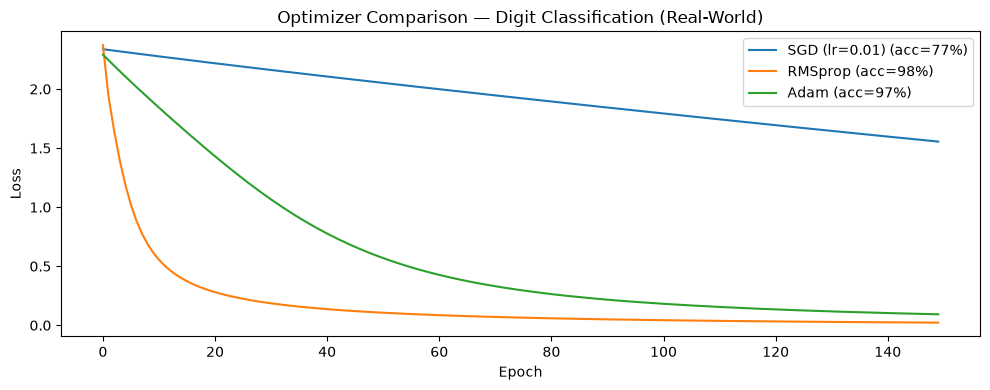

In [4]:
# WHAT: train the same small network three times, changing only the optimizer (SGD, RMSprop, Adam).
# WHY: with data, model and epochs held fixed, any difference in the loss curves comes from the update rule alone.
import torch, torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# Load the 8x8 digits dataset and standardize features so all optimizers start from comparable conditions.
digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr = torch.tensor(X_tr); Ytr = torch.tensor(y_tr, dtype=torch.long)
Xte = torch.tensor(X_te); Yte = torch.tensor(y_te, dtype=torch.long)

# A fresh model per optimizer - reusing weights would contaminate the comparison.
def make_model():
    return nn.Sequential(nn.Linear(64,128), nn.ReLU(), nn.Linear(128,10))

# The three contenders: plain SGD, RMSprop (adaptive step per weight), Adam (adaptive step + momentum).
optimizers = {
    'SGD (lr=0.01)':   lambda m: torch.optim.SGD(m.parameters(), lr=0.01),
    'RMSprop':         lambda m: torch.optim.RMSprop(m.parameters(), lr=1e-3),
    'Adam':            lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),
}
results = {}
# Train 150 full-batch steps per optimizer and record the loss after each one.
for name, opt_fn in optimizers.items():
    model = make_model()
    opt   = opt_fn(model)
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for _ in range(150):
        model.train()
        loss = loss_fn(model(Xtr), Ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(loss.item())
    # Measure test accuracy with gradients off - training is done, we only evaluate.
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1)==Yte).float().mean().item()
    results[name] = (curve, acc)
    print(f"{name:20s} → final acc: {acc*100:.1f}%")

# One curve per optimizer: the faster-falling loss is the faster learner on this task.
plt.figure(figsize=(10,4))
for name,(curve,acc) in results.items():
    plt.plot(curve, label=f"{name} (acc={acc*100:.0f}%)")
plt.title("Optimizer Comparison — Digit Classification (Real-World)"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

## 💬 Discuss

1. Our file is **616.9 KB** for a two-layer MNIST model. Before optimising anything, what would you need to measure to know whether size is even your problem? Name the measurement and the number that would make you stop.
2. You have a model that is 5% more accurate and 20× larger. Name a deployment target where you take the accuracy, and one where you refuse it. What changes between the two?
3. Save and load worked here in a single cell. List three things that can go wrong between your laptop and a production server that this cell would never catch — and say how you would test for each one before shipping.


## ⚠️ Where this breaks

- **Save/load is not versioning.** Writing over `model.keras` destroys whatever is currently in production and leaves you no way back. A serving stack (`02`) exists partly to hold several versions at once precisely so this cannot happen.
- **Loading a model file is running code.** `.keras` and `.h5` files carry architecture as well as weights, and loading them re-executes model definitions. A model file from an untrusted source is untrusted code — doubly so for `pickle`, which Course 11 covers. Never load a `.pkl` a stranger sent you.
- **Version skew is the failure students actually hit.** A model saved by one Keras or PyTorch major version does not reliably load in another. Pin your versions in the same place you store the artifact, or your "deployed" model is a time bomb.
- **The file is not the system.** Sculley et al. (NeurIPS 2015) argued that ML code is only a small fraction of a real ML system; the rest is data collection, feature extraction, configuration, serving and monitoring. A perfect `.keras` file with no monitoring is an unmonitored model, and it will drift without telling you.
- **A note on this notebook's own worked example:** the optimizer comparison at the end is shared across several notebooks in this course and is about *optimizers*, not deployment. Treat it as revision. The evidence for *this* lesson is the 616.9 KB file and the successful reload — nothing more.


## 🧩 Mini-exercise

**Try it:** Save the same model again with a different path (e.g. `model_epoch3.keras`) after training. Load it in a new cell and run one prediction to confirm it matches the in-memory model.

---

## ✅ Summary

**What you did:** Built and trained a small model, **saved** it, **loaded** it, and ran a sample prediction. This is the basis for deployment; optimization (quantization, pruning) reduces size and latency.

**In real life you'd also:** Convert to TFLite/ONNX, apply quantization and pruning, and deploy via Flask/FastAPI or TensorFlow Serving.

**The main idea:** Save/load lets us deploy the same model elsewhere; optimization (quantization, pruning) makes it smaller and faster for edge and mobile.

**Next:** `07_model_optimization_quantization` and `06_flask_fastapi_deployment` cover quantization and API deployment.

## 📚 References

1. Han, S., Mao, H. & Dally, W. J. (2016). *Deep Compression: Compressing Deep Neural Networks with Pruning, Trained Quantization and Huffman Coding*. ICLR. https://arxiv.org/abs/1510.00149
2. Hinton, G., Vinyals, O. & Dean, J. (2015). *Distilling the Knowledge in a Neural Network*. arXiv. https://arxiv.org/abs/1503.02531
3. Menghani, G. (2021). *Efficient Deep Learning: A Survey on Making Deep Learning Models Smaller, Faster, and Better*. arXiv. https://arxiv.org/abs/2106.08962